# Non-energy industrial goods (NEIG) — Bayesian sparse ARX(12) with SV and model-based outliers

This notebook is the third model of the **Headline inflation suite**.

The economic specification follows **ECB Working Paper 374 (2004)**. For euro-area non-energy industrial goods, the selected model is a **dynamic single equation**, not the full BVAR that obtained a slightly lower RMSE. The authors reject that full BVAR because its impulse responses were not economically intuitive.

The selected equation contains:

- HICP NEIG lags **1, 6 and 12**;
- producer prices of consumer goods at lag **1**;
- compensation per employee at lag **2**;
- the contemporaneous standard VAT rate;
- 11 monthly seasonal dummies.

The 6th lag is economically motivated by the two major sales periods that typically occur each year. The 12th lag captures annual seasonality.

The Bayesian disturbance and uncertainty machinery is inherited from the validated Energy suite / ECB WP 3062 project implementation:

- Minnesota-style normal shrinkage for estimated autoregressive coefficients;
- stochastic volatility;
- model-based transitory outliers;
- Durbin–Koopman data augmentation when the endogenous target has missing/ragged-edge observations;
- the same forecast/result/registry contract used by the dashboard.

Unlike the earlier Unprocessed Food approximation, this NEIG implementation enforces the endogenous lag set **exactly**. Lags 2–5 and 7–11 are fixed to zero in every posterior draw; only lags 1, 6 and 12 are sampled.

## Econometric representation

Let

\[
y_t = \Delta \log I_t^{NEIG},
\]

where \(I_t^{NEIG}\) is the non-seasonally-adjusted HICP NEIG index. The exact WP374 lag structure is

\[
y_t = c
+ \beta_1 y_{t-1}
+ \beta_6 y_{t-6}
+ \beta_{12}y_{t-12}
+ \gamma\,\Delta\log PPI^{CONS}_{t-1}
+ \delta\,\Delta\log WAGE_{t-2}
+ \theta\,\Delta(VAT_t/100)
+ d_t'\eta
+ \nu_t.
\]

The omitted endogenous lags are **restrictions**, not strongly shrunk coefficients:

\[
\beta_2=\cdots=\beta_5=\beta_7=\cdots=\beta_{11}=0.
\]

The innovation follows the same univariate SV/outlier decomposition as the Energy engine:

\[
\nu_t=o_t\sqrt{\lambda_t}\varepsilon_t,
\qquad
\log\lambda_t=\log\lambda_{t-1}+\eta_t.
\]

VAT is stored natively in percentage points (for example `20.5`) and converted to a rate share (`0.205`) before differencing.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import os
import sys
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/ and src/.")


env_root = os.environ.get("BVAR_PROJECT_ROOT")
PROJECT_ROOT = (
    Path(env_root).expanduser().resolve()
    if env_root
    else find_project_root(Path.cwd())
)
MODEL_DIR = PROJECT_ROOT / "src" / "model"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from headline_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    forecast_headline_component,
    headline_component_contract_table,
    headline_component_spec,
    headline_driver_assumption_table,
    headline_forecast_horizon_table,
    headline_panel_audit,
    headline_scenario_impact_table,
    headline_series_construction_table,
    headline_transformation_table,
    load_headline_component_panel,
    native_model_differences,
    prepare_headline_component,
    resolve_headline_component_dataset,
    run_headline_bvar,
    sparse_lag_restriction_table,
    wp374_neig_posterior_comparison,
    wp374_neig_sparse_benchmark,
)

from headline_bvar_plot import (
    plot_headline_driver_assumptions,
    plot_headline_hicp_forecast_fan,
    plot_headline_model_differences,
    plot_headline_native_levels,
    plot_headline_scenario_impact,
)

from energy_bvar_model import (
    coefficient_posterior_table,
    mcmc_diagnostics,
    posterior_predictive_statistics,
    residual_diagnostic_table,
    stability_diagnostics,
    stationarity_tests,
)

from energy_bvar_plot import (
    plot_chain_acf_grid,
    plot_outlier_probabilities,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_posterior_volatility,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    style_numeric_table,
)

try:
    from energy_bvar_io import save_energy_bvar_result
except ImportError:
    save_energy_bvar_result = None

COMPONENT = "neig"
SPEC = headline_component_spec(COMPONENT)

# None -> data/processed. During development this can point to a scratch build.
DATA_ROOT = None
VINTAGE = None

QUICK_TEST = False
FORECAST_HORIZON = 18
FORECAST_DRAWS = 250 if QUICK_TEST else 1_000
SAVE_RESULTS = False

# Explicitly mirror the validated Energy-suite production calibration.
PRIOR_CONFIG = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
SAMPLER_CONFIG = SamplerConfig(
    reps=300 if QUICK_TEST else 6_000,
    burn=150 if QUICK_TEST else 3_000,
    thin=1,
    seed=42,
    max_stability_tries=1_000,
    progress_every=0 if QUICK_TEST else 500,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("COMPONENT:", COMPONENT)
print("Implementation:", SPEC["implementation_mode"])
print("Maximum companion lag p:", SPEC["p"])
print("Estimated endogenous lags:", SPEC["active_lags"])

PROJECT_ROOT: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
COMPONENT: neig
Implementation: bayesian_sparse_arx12_sv_outlier_exact_wp374_lag_structure
Maximum companion lag p: 12
Estimated endogenous lags: [1, 6, 12]


## 2. Paper contract and transformation contract

In [2]:
display(headline_component_contract_table())
display(headline_transformation_table(COMPONENT))

,label,dataset_file,target,paper_model_class,paper_lag_structure,active_lags,implementation_mode,production_ready,production_blocker
component,,,,,,,,,
unprocessed_food,Unprocessed food,unprocessed_food_monthly.csv,hicp_unprocessed_food,dynamic single equation / autoregression,"HICP unprocessed food L1, L10, L12 + 11 monthl...",None,dense_bayesian_ar12_shrinkage_approximation,True,None
processed_food,Processed food,processed_food_monthly.csv,hicp_processed_food,dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,"[1, 2, 3, 4]",bayesian_arx4_sv_outlier_exact_wp374_lag_struc...,True,None
neig,Non-energy industrial goods,neig_monthly.csv,hicp_neig,dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...","[1, 6, 12]",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...,True,None
services,Services,services_monthly.csv,hicp_services,BVAR,Services/wages/PPI consumer goods/unprocessed ...,"[1, 2, 3, 4, 5, 12]",bayesian_sparse_bvar12_sv_outlier_exact_wp374_...,True,None


,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags
native_series,,,,,,,
hicp_neig,target,HICP index,logdiff,log(hicp_neig),Δlog(hicp_neig),state__hicp_neig,"[1, 6, 12]"
ppi_consumer_goods,driver,PPI consumer-goods index,logdiff,log(ppi_consumer_goods),Δlog(ppi_consumer_goods),state__ppi_consumer_goods,[1]
compensation_per_employee,driver,compensation per employee,logdiff,log(compensation_per_employee),Δlog(compensation_per_employee),state__compensation_per_employee,[2]
vat_standard_ea,driver,% standard VAT rate,percent_rate_diff,vat_standard_ea/100,Δ(vat_standard_ea/100),state__vat_standard_ea,[0]


The transformation layer is the same architecture used by the other Headline components:

- `hicp_neig`: native HICP index → log state → first difference;
- `ppi_consumer_goods`: native PPI index → log state → first difference;
- `compensation_per_employee`: native level/index → log state → first difference;
- `vat_standard_ea`: percentage-point rate → rate share (`/100`) → first difference.

Only `hicp_neig` is endogenous. The PPI, wage and VAT terms are built as exogenous regressors at their exact WP374 lags.

## 3. Load and audit the native panel

In [3]:
DATASET_PATH = resolve_headline_component_dataset(
    PROJECT_ROOT,
    COMPONENT,
    vintage=VINTAGE,
    data_root=DATA_ROOT,
)
VINTAGE_USED = DATASET_PATH.parent.name
native_levels = load_headline_component_panel(DATASET_PATH, COMPONENT)

print("Dataset:", DATASET_PATH)
print("Vintage:", VINTAGE_USED)
display(headline_series_construction_table(DATASET_PATH, COMPONENT))
display(headline_panel_audit(native_levels, COMPONENT))

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260811\neig_monthly.csv
Vintage: 20260811


,dataset_file,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags,paper_model_class,paper_lag_structure,implementation_mode
native_series,,,,,,,,,,,
hicp_neig,neig_monthly.csv,target,HICP index,logdiff,log(hicp_neig),Δlog(hicp_neig),state__hicp_neig,"[1, 6, 12]",dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...
ppi_consumer_goods,neig_monthly.csv,driver,PPI consumer-goods index,logdiff,log(ppi_consumer_goods),Δlog(ppi_consumer_goods),state__ppi_consumer_goods,[1],dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...
compensation_per_employee,neig_monthly.csv,driver,compensation per employee,logdiff,log(compensation_per_employee),Δlog(compensation_per_employee),state__compensation_per_employee,[2],dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...
vat_standard_ea,neig_monthly.csv,driver,% standard VAT rate,percent_rate_diff,vat_standard_ea/100,Δ(vat_standard_ea/100),state__vat_standard_ea,[0],dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...


,role,unit,first_observed,last_observed,n_calendar,n_observed,n_missing,missing_share
series,,,,,,,,
hicp_neig,target,HICP index,1999-12-01,2026-07-01,320,320,0,0.000000
ppi_consumer_goods,exogenous_driver,PPI consumer-goods index,2000-01-01,2026-06-01,320,318,2,0.006250
compensation_per_employee,exogenous_driver,compensation per employee,2000-03-01,2026-03-01,320,313,7,0.021875
vat_standard_ea,exogenous_driver,% standard VAT rate,1999-12-01,2026-07-01,320,320,0,0.000000


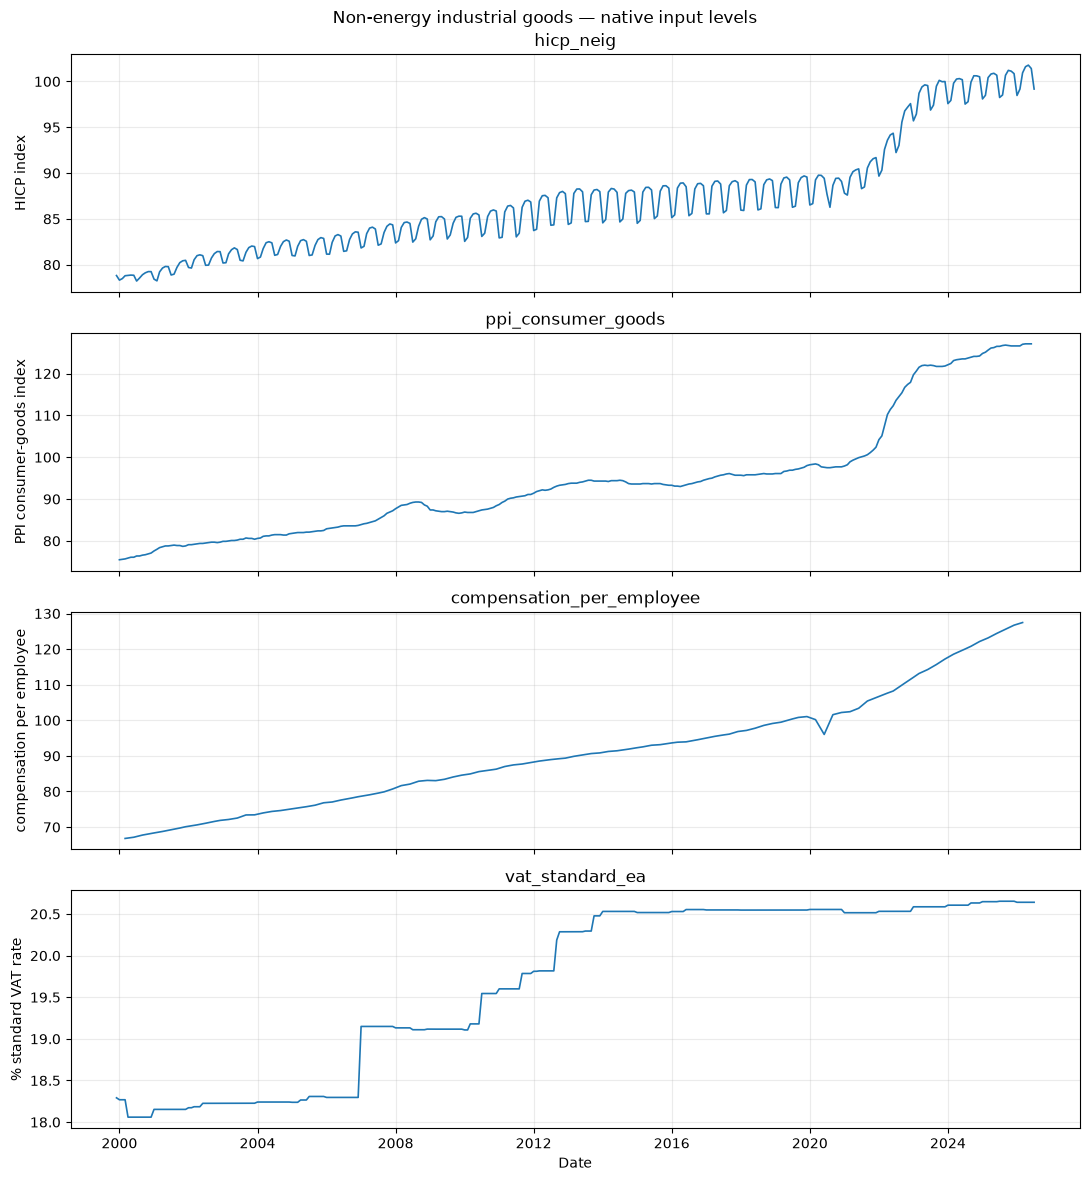

In [4]:
plot_headline_native_levels(
    native_levels,
    component_label=SPEC["label"],
    units=SPEC["units"],
)
plt.show()

## 4. Model-space transformations

,count,mean,std,min,25%,50%,75%,max
hicp_neig,319.0,0.000720,0.015364,-0.039667,-0.002194,0.001513,0.006491,0.037372
ppi_consumer_goods,317.0,0.001643,0.003230,-0.010245,0.000000,0.001195,0.002381,0.024806
compensation_per_employee,312.0,0.002071,0.002584,-0.014491,0.001359,0.001862,0.002727,0.018934
vat_standard_ea,319.0,0.000074,0.000598,-0.002091,0.000000,0.000000,0.000000,0.008526


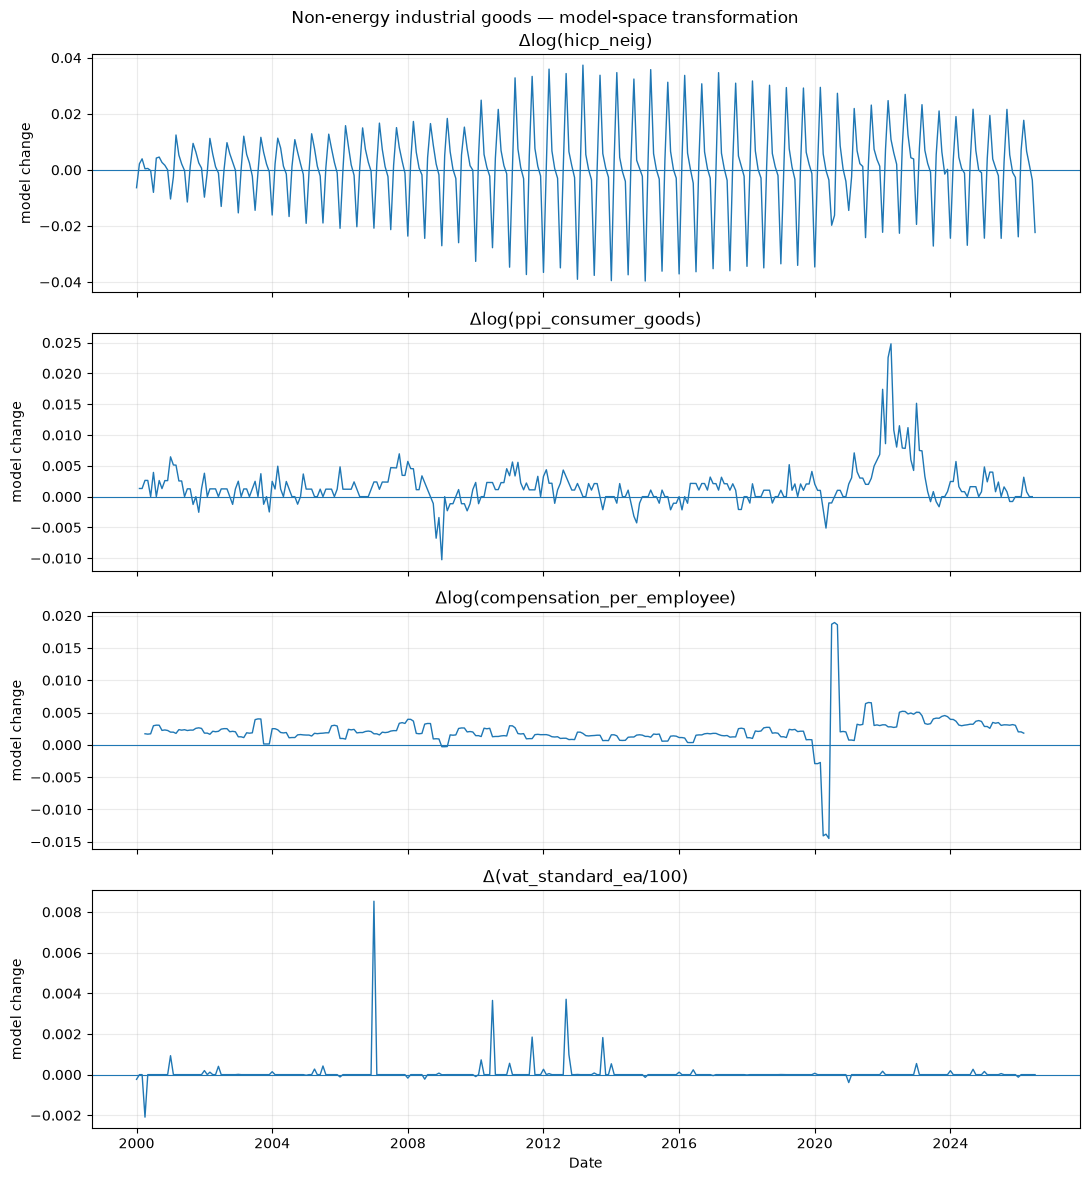

In [5]:
model_differences = native_model_differences(native_levels, COMPONENT)
transform_labels = headline_transformation_table(COMPONENT)["model_change"].to_dict()

display(model_differences.describe().T)
plot_headline_model_differences(
    model_differences,
    component_label=SPEC["label"],
    transform_labels=transform_labels,
)
plt.show()

## 5. Build the exact sparse ARX design

The shared Energy engine still retains a full 12-lag companion state. This matters for stability checks, forecasting and DK smoothing. However, the coefficient sampler now accepts an optional `active_lags` restriction.

For NEIG:

```text
estimated endogenous lags : 1, 6, 12
fixed exactly to zero      : 2, 3, 4, 5, 7, 8, 9, 10, 11

external regressors:
PPI consumer goods         : L1
compensation per employee  : L2
VAT                        : L0
seasonality                : month_01 ... month_11
```

This is therefore an exact sparse Bayesian version of the selected WP374 lag structure, rather than a dense AR(12) approximation.

In [6]:
prepared = prepare_headline_component(native_levels, COMPONENT)

print("Endogenous state columns:", list(prepared["state_levels"].columns))
print("Active endogenous lags:", SPEC["active_lags"])
print("Exogenous design columns:")
for name in prepared["exog"].columns:
    print("  ", name)
print("First regression date:", prepared["first_regression_date"])
print("Model calendar starts:", prepared["model_start"])

display(prepared["predictor_edge_audit"])

Endogenous state columns: ['state__hicp_neig']
Active endogenous lags: [1, 6, 12]
Exogenous design columns:
   ppi_consumer_goods_L1
   compensation_per_employee_L2
   vat_standard_ea_L0
   month_01
   month_02
   month_03
   month_04
   month_05
   month_06
   month_07
   month_08
   month_09
   month_10
   month_11
First regression date: 2000-06-01 00:00:00
Model calendar starts: 1999-12-01 00:00:00


,first_observed,last_observed,trailing_months_conditioned,edge_policy
driver,,,,
ppi_consumer_goods,2000-01-01,2026-06-01,1,flat_native_level
compensation_per_employee,2000-03-01,2026-03-01,4,flat_native_level
vat_standard_ea,1999-12-01,2026-07-01,0,flat_native_level


### Ragged-edge treatment of PPI, wages and VAT

These variables are exogenous in the selected WP374 equation. We therefore do **not** pretend that the DK smoother can jointly nowcast them as endogenous VAR states.

The current conditioning contract is explicit:

- an interior missing value in an exogenous driver is rejected;
- only a trailing missing edge can be conditioned;
- the latest native driver level is carried forward, implying zero additional transformed change;
- every conditioned trailing month is surfaced in the audit table.

This is a forecast assumption, not an observed-data imputation.

## 6. Exact WP374 OLS benchmark

In [7]:
wp374 = wp374_neig_sparse_benchmark(native_levels)

display(wp374["comparison"])
print("Current benchmark sample:", wp374["data"].index.min(), "→", wp374["data"].index.max())
print("R²:", round(float(wp374["fit"].rsquared), 4))
print("VAT normalization:", wp374["vat_normalisation"])

,WP374_reported,current_sample
HICP_L1,-0.0488,-0.021793
HICP_L6,0.4536,0.584084
HICP_L12,0.3302,0.273119
PPI_L1,0.1301,0.128837
WAGES_L2,0.0682,0.037852
VAT_L0,0.0579,0.324631


Current benchmark sample: 2001-01-01 00:00:00 → 2026-05-01 00:00:00
R²: 0.9762
VAT normalization: native percentage points / 100 before first difference


Appendix A4 reports approximately:

```text
HICP NEIG L1     -0.0488
HICP NEIG L6      0.4536
HICP NEIG L12     0.3302
PPI CONS L1       0.1301
WAGES L2          0.0682
VAT L0            0.0579
```

These 2004 numerical estimates are a historical benchmark, not a replication target for the modern sample. In particular, the current official series, classification, VAT construction and estimation window differ materially from the 1990–2002 sample used in the paper.

## 7. Bayesian priors

In [8]:
display(pd.Series(asdict(PRIOR_CONFIG), name="value").to_frame())
display(pd.Series(asdict(SAMPLER_CONFIG), name="value").to_frame())

,value
lambda1,2.000000e-01
lambda2,5.000000e-01
lambda3,1.000000e+00
lambda4,1.000000e+01
a_prior_var,1.000000e+01
phi_prior_mean,2.000000e-02
phi_prior_df,1.000000e+01
h0_var,4.000000e+00
outlier_mean_frequency,2.083333e-02
outlier_prior_observations,1.200000e+02


,value
reps,6000
burn,3000
thin,1
seed,42
max_stability_tries,1000
progress_every,500
sv_sampler,centered_ksc
dk_projection_mode,strict
dk_level_relative_gate,0.000001
dk_difference_relative_gate,0.000001


The prior calibration is deliberately the same as the validated Energy suite. The 2004 paper's selected NEIG model is a single equation, so we do **not** import the hyperparameters from its alternative full BVAR. The modernisation is the Energy-suite Bayesian uncertainty/volatility machinery applied to the selected NEIG economics.

For the sparse target dynamics, omitted lags have a **degenerate zero restriction**, not merely a tight Minnesota prior.

## 8. Gibbs estimation

In [9]:
result = run_headline_bvar(
    prepared,
    component=COMPONENT,
    vintage=VINTAGE_USED,
    prior_config=PRIOR_CONFIG,
    sampler_config=SAMPLER_CONFIG,
    exog_prior_scale=10.0,
    code_version="headline-neig-sparse-v1",
)

print("Run ID:", result["metadata"]["run_id"])
print("Posterior draws:", result["n_draws"])
print("Endogenous variables:", result["variables"])
print("Maximum companion lag:", result["p"])
print("Active lags:", result["active_lags"])
print("Balanced end:", result["prep"]["balanced_end"])
print("Exogenous regressors:", result["prep"]["exog_names"])

iteration 500/6,000 | B instability rejection 0.00% | radius 0.8849
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8916
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.9023
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.9168
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.9017
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.9087
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.8927
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8888
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.9027
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.8973
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.9039
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.8830
Run ID: f806027fc98f88ef83b2b0265e12df9dcc4fab1f7ec404269251cf05f359eac4
Posterior draws: 3000
Endogenous variables: ['state__hicp_neig']
Maximum companion lag: 1

## 9. Hard audit of the sparse endogenous lag restrictions

In [10]:
lag_audit = sparse_lag_restriction_table(result)
display(lag_audit)

inactive = [2, 3, 4, 5, 7, 8, 9, 10, 11]
assert lag_audit.loc[inactive, "max_abs_posterior_coefficient"].max() == 0.0
assert set(result["active_lags"]) == {1, 6, 12}
print("PASS — every omitted endogenous lag is exactly zero in every retained posterior draw.")

,status,max_abs_posterior_coefficient
lag,,
1,estimated,0.130918
2,fixed_zero,0.000000
3,fixed_zero,0.000000
4,fixed_zero,0.000000
5,fixed_zero,0.000000
6,estimated,0.491439
7,fixed_zero,0.000000
8,fixed_zero,0.000000
9,fixed_zero,0.000000


PASS — every omitted endogenous lag is exactly zero in every retained posterior draw.


This audit is stronger than checking whether a posterior interval happens to contain zero. It verifies the actual model restriction: inactive lag coefficients are not sampled at all and remain exactly zero draw-by-draw.

## 10. Posterior coefficients and WP374 comparison

In [11]:
coef = coefficient_posterior_table(result)
display(style_numeric_table(coef, caption="NEIG posterior coefficients"))

display(
    style_numeric_table(
        wp374_neig_posterior_comparison(result),
        caption="WP374 reported coefficients vs modern Bayesian posterior",
    )
)

,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
state__hicp_neig: const,0.00,0.15,-3.91 × 10⁻⁴,-3.77 × 10⁻⁴,5.36 × 10⁻⁴,-1.28 × 10⁻³,-9.13 × 10⁻⁴,1.29 × 10⁻⁴,4.90 × 10⁻⁴,434.79
state__hicp_neig: state__hicp_neig L1,0.00,0.20,-1.35 × 10⁻³,-1.04 × 10⁻³,0.04,-0.07,-0.04,0.04,0.06,169.97
state__hicp_neig: state__hicp_neig L2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00
state__hicp_neig: state__hicp_neig L3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00
state__hicp_neig: state__hicp_neig L4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00
state__hicp_neig: state__hicp_neig L5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00
state__hicp_neig: state__hicp_neig L6,0.00,0.03,0.33,0.33,0.04,0.26,0.28,0.37,0.40,64.81
state__hicp_neig: state__hicp_neig L7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00
state__hicp_neig: state__hicp_neig L8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00
state__hicp_neig: state__hicp_neig L9,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00


,WP374_reported,posterior_median,q16,q84,posterior_sd,ESS
term,,,,,,
HICP_L1,-0.05,-1.04 × 10⁻³,-0.04,0.04,0.04,169.97
HICP_L6,0.45,0.33,0.28,0.37,0.04,64.81
HICP_L12,0.33,0.09,0.07,0.11,0.02,111.43
PPI_L1,0.13,0.15,0.10,0.21,0.05,413.90
WAGES_L2,0.07,9.89 × 10⁻³,-0.07,0.09,0.08,508.15
VAT_L0,0.06,0.15,0.03,0.27,0.12,2449.94


## 11. Stochastic volatility, outliers and residual diagnostics

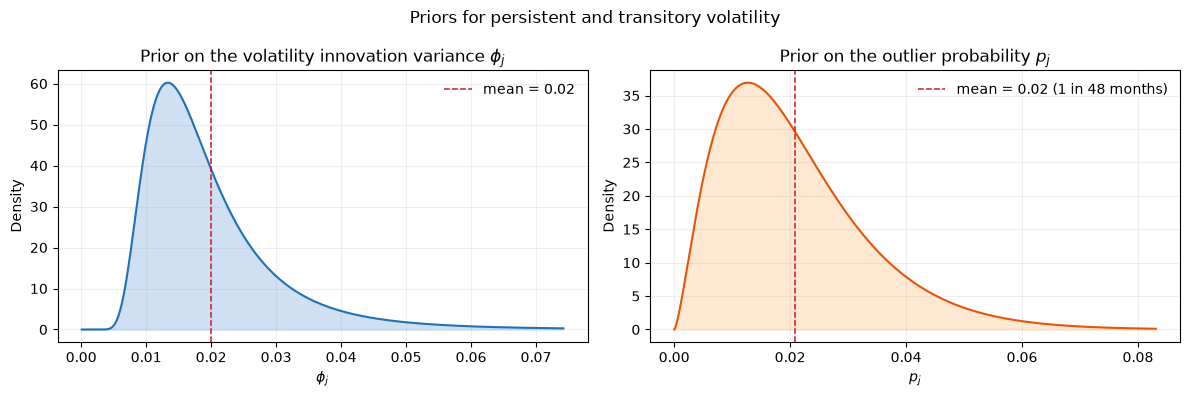

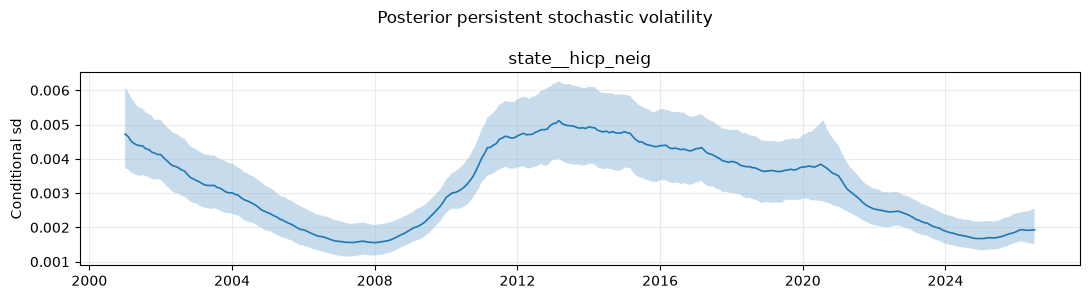

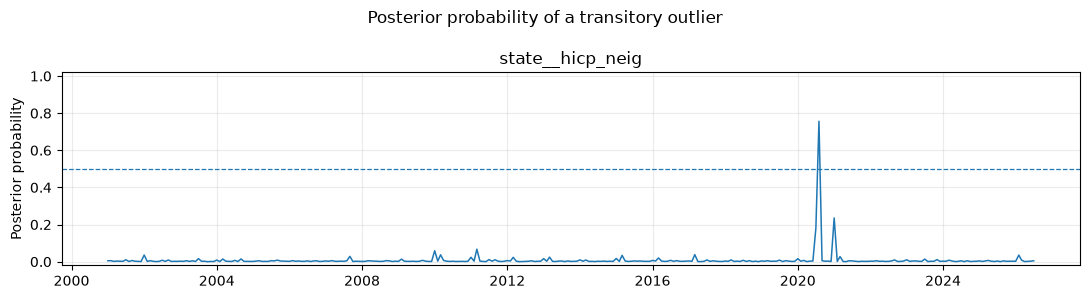

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
state__hicp_neig,0.02,0.95,0.26,0.39,-4.65 × 10⁻⁴,2.86


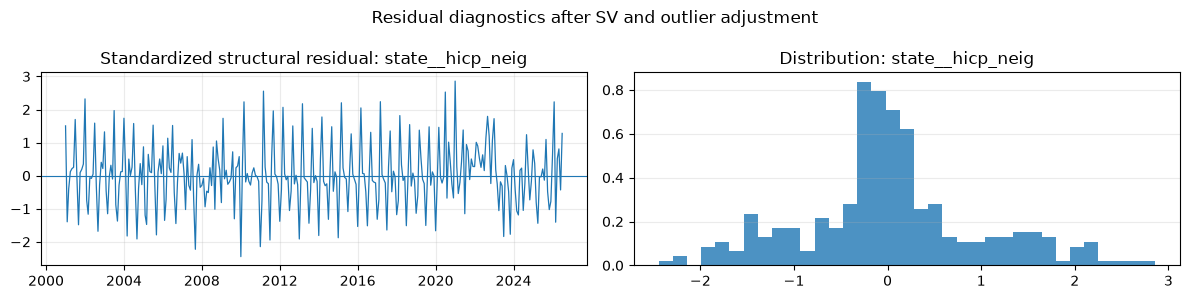

In [12]:
plot_phi_and_outlier_priors(result["prior"])
plt.show()

plot_posterior_volatility(result, include_outliers=False)
plt.show()

plot_outlier_probabilities(result)
plt.show()

residual_diag = residual_diagnostic_table(result)
display(style_numeric_table(residual_diag, caption="Residual diagnostics"))
plot_standardized_residuals(result)
plt.show()

NEIG has an additional practical reason for retaining the modern SV/outlier layer: the component is strongly affected by sales-season dynamics and historical statistical changes. WP374 explicitly discusses the 2001 introduction of sales prices in the HICP for Italy and Spain and reconstructs back data to mitigate the break. Our current official aggregate series is not manually back-corrected in the same way; stochastic volatility and transitory outlier states provide a transparent modern treatment of unusual observations without altering the raw official history.

## 12. Baseline conditional forecast

The selected NEIG equation contains external regressors, so its forecast is conditional on paths for PPI consumer goods, wages and VAT.

The default dashboard baseline uses a transparent **flat-native-level** assumption for each external driver beyond its latest available/conditioned observation. This means zero additional transformed changes after the forecast origin, while the first forecast months still inherit the historical lag structure where required.

In [13]:
baseline = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=True,
    seed=2026,
)

print("Forecast contract:", baseline["forecast_contract_version"])
print("Driver policy:", baseline["driver_forecast_policy"])
display(headline_driver_assumption_table(result))

Forecast contract: headline-hicp-component-v1
Driver policy: flat_native_level


,first_observed,last_observed,trailing_months_conditioned,edge_policy
driver,,,,
ppi_consumer_goods,2000-01-01,2026-06-01,1,flat_native_level
compensation_per_employee,2000-03-01,2026-03-01,4,flat_native_level
vat_standard_ea,1999-12-01,2026-07-01,0,flat_native_level


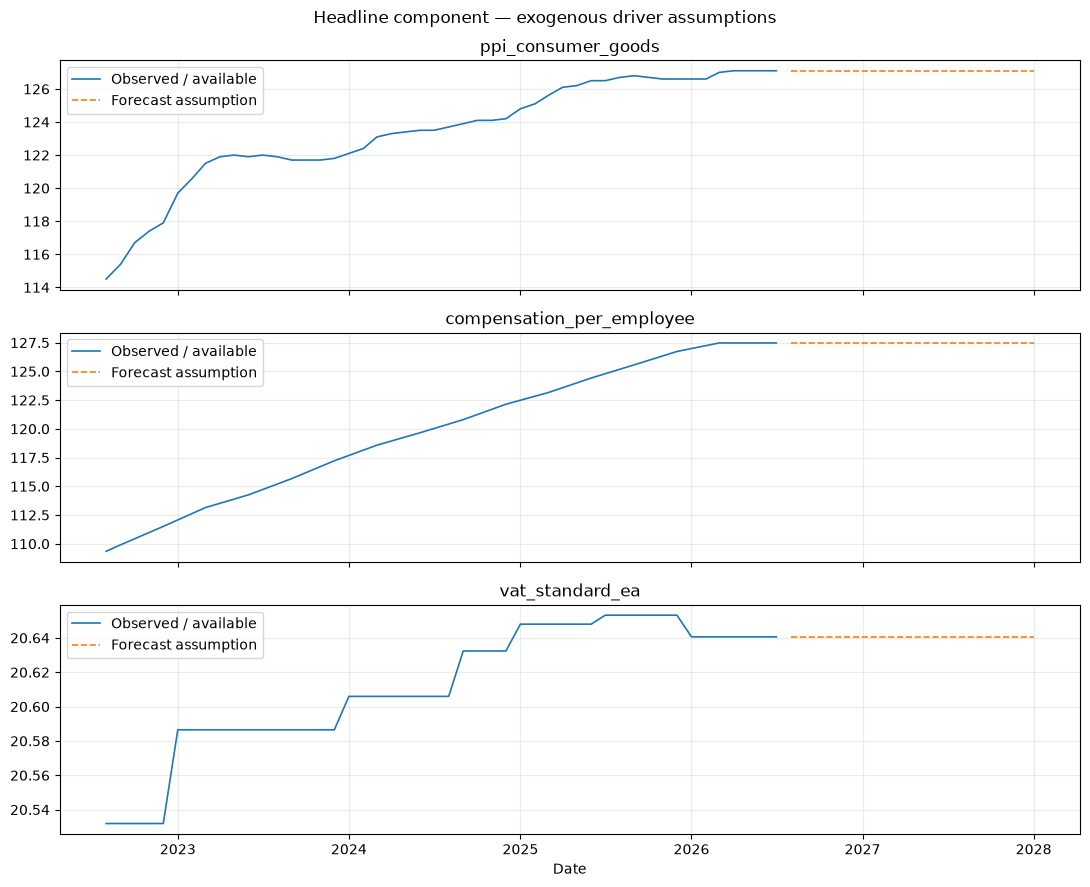

In [14]:
plot_headline_driver_assumptions(
    prepared["design_native_levels"],
    baseline,
    last_obs=48,
)
plt.show()

In [15]:
print("HICP NEIG index")
display(headline_forecast_horizon_table(baseline, kind="level"))

print("HICP NEIG YoY inflation")
display(headline_forecast_horizon_table(baseline, kind="yoy"))

HICP NEIG index


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,99.205379,99.357911,99.565796,99.801932,99.969704
3,2026-10-01,101.527044,101.765747,102.135622,102.559200,102.977900
6,2027-01-01,98.454794,99.055038,99.650410,100.209415,100.708390
12,2027-07-01,97.810222,98.840325,99.802767,100.792075,101.813223
18,2028-01-01,97.215174,98.737898,100.164935,101.610876,103.300574


HICP NEIG YoY inflation


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,0.695675,0.850499,1.061507,1.301189,1.471482
3,2026-10-01,0.313254,0.549102,0.914556,1.333069,1.746764
6,2027-01-01,-0.015442,0.594128,1.198751,1.766442,2.273169
12,2027-07-01,-1.371158,-0.332434,0.638063,1.635651,2.665346
18,2028-01-01,-1.771978,-0.529108,0.572732,1.537826,2.820765


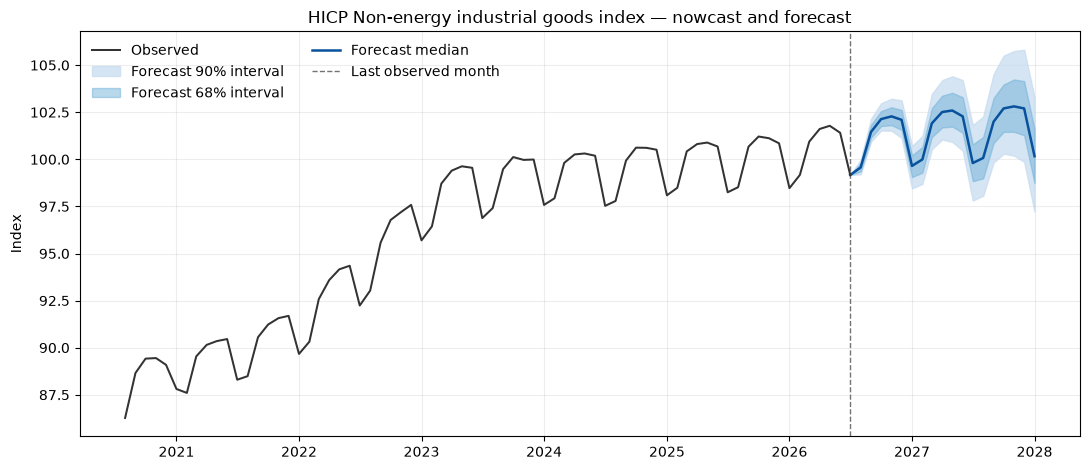

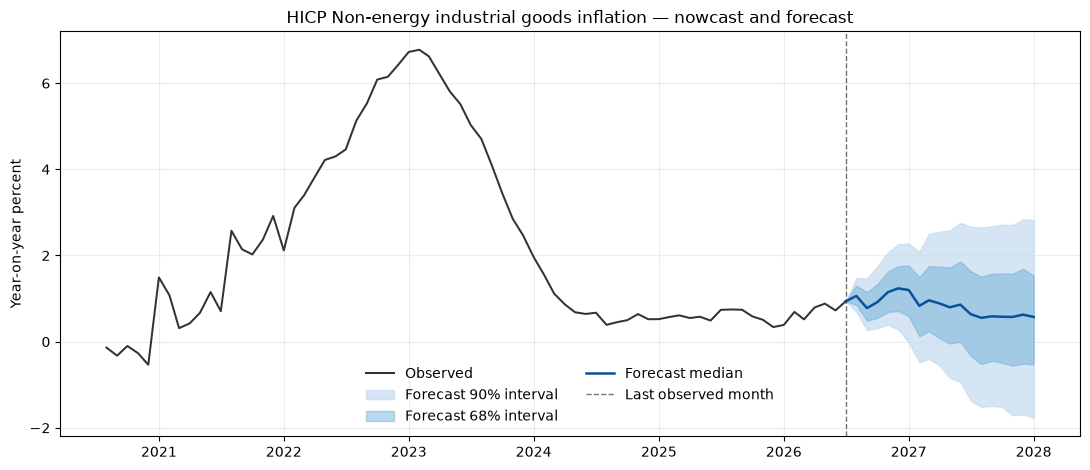

In [16]:
plot_headline_hicp_forecast_fan(baseline, kind="level", last_obs=72)
plt.show()

plot_headline_hicp_forecast_fan(baseline, kind="yoy", last_obs=72)
plt.show()

## 13. Conditional sensitivity experiments

WP374 evaluates the economic plausibility of the selected NEIG equation by perturbing its external drivers. We implement the same idea as **conditional path sensitivities**, not as structurally identified shocks.

For comparability with the paper, the experiments below use:

- PPI consumer goods: permanent **+1%** level shift;
- compensation per employee: permanent **+1%** level shift;
- VAT rate: permanent **+1% relative** shift in the VAT rate.

The same posterior/random innovations are used for each scenario-baseline pair (`simulate_future_outliers=False` and identical seeds), so their difference isolates the changed driver path as cleanly as possible.

In [17]:
H = FORECAST_HORIZON
last_used = prepared["design_native_levels"].ffill().iloc[-1]
N_SCENARIO_DRAWS = min(FORECAST_DRAWS, result["n_draws"])

# PPI consumer goods: +1% permanent level shift.
ppi_baseline = forecast_headline_component(
    result, component=COMPONENT, H=H, native_levels=native_levels,
    n_draws=N_SCENARIO_DRAWS, simulate_future_outliers=False, seed=701,
)
ppi_scenario = forecast_headline_component(
    result, component=COMPONENT, H=H, native_levels=native_levels,
    n_draws=N_SCENARIO_DRAWS, simulate_future_outliers=False, seed=701,
    native_driver_paths={
        "ppi_consumer_goods": float(last_used["ppi_consumer_goods"]) * 1.01,
    },
)

# Compensation per employee: +1% permanent level shift.
wage_baseline = forecast_headline_component(
    result, component=COMPONENT, H=H, native_levels=native_levels,
    n_draws=N_SCENARIO_DRAWS, simulate_future_outliers=False, seed=702,
)
wage_scenario = forecast_headline_component(
    result, component=COMPONENT, H=H, native_levels=native_levels,
    n_draws=N_SCENARIO_DRAWS, simulate_future_outliers=False, seed=702,
    native_driver_paths={
        "compensation_per_employee": float(last_used["compensation_per_employee"]) * 1.01,
    },
)

# VAT: +1% RELATIVE shift in the rate (e.g. 20.0% -> 20.2%), matching the
# wording of the NEIG sensitivity experiment in WP374. This differs from +1 pp.
vat_baseline = forecast_headline_component(
    result, component=COMPONENT, H=H, native_levels=native_levels,
    n_draws=N_SCENARIO_DRAWS, simulate_future_outliers=False, seed=703,
)
vat_scenario = forecast_headline_component(
    result, component=COMPONENT, H=H, native_levels=native_levels,
    n_draws=N_SCENARIO_DRAWS, simulate_future_outliers=False, seed=703,
    native_driver_paths={
        "vat_standard_ea": float(last_used["vat_standard_ea"]) * 1.01,
    },
)

Permanent +1% PPI consumer-goods level shift


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,0.000000,0.000000,0.000000,0.000000,0.000000
2,2026-09-01,0.062533,0.099647,0.155392,0.207360,0.241269
3,2026-10-01,0.063758,0.100389,0.155661,0.205433,0.239837
6,2027-01-01,0.064642,0.100429,0.156048,0.207133,0.241388
12,2027-07-01,0.085082,0.133865,0.205266,0.274054,0.316359
18,2028-01-01,0.033637,0.051395,0.078927,0.108310,0.124614


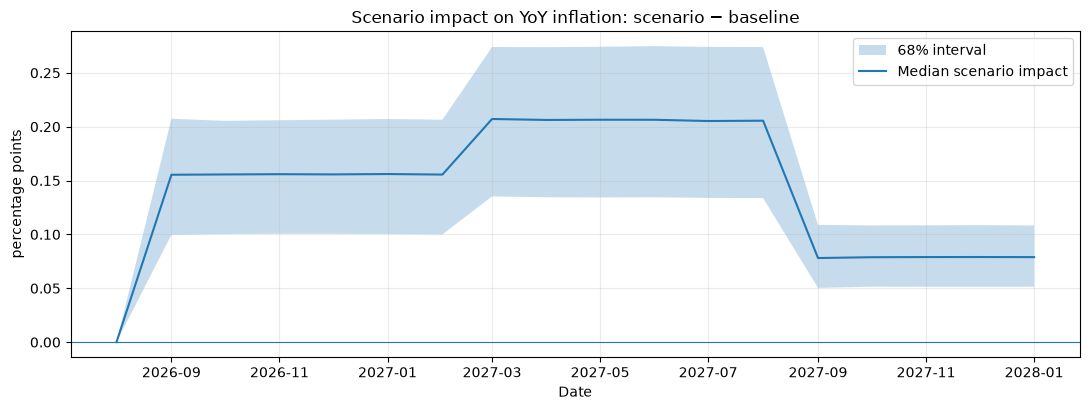

Permanent +1% compensation-per-employee level shift


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,0.000000,0.000000,0.000000,0.000000,0.000000
2,2026-09-01,0.000000,0.000000,0.000000,0.000000,0.000000
3,2026-10-01,-0.123534,-0.069882,0.011905,0.092764,0.149042
6,2027-01-01,-0.124043,-0.069940,0.011554,0.092275,0.146268
12,2027-07-01,-0.161806,-0.090690,0.015507,0.123096,0.194533
18,2028-01-01,-0.064722,-0.036373,0.006236,0.047862,0.079570


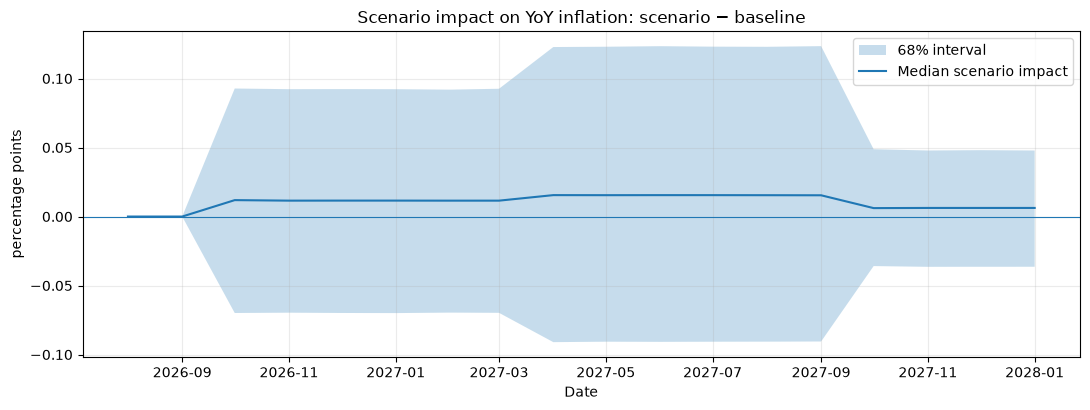

Permanent +1% RELATIVE VAT-rate shift


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,-0.014433,0.003490,0.028743,0.054414,0.072162
2,2026-09-01,-0.014250,0.003411,0.028463,0.054067,0.071379
3,2026-10-01,-0.014308,0.003419,0.028531,0.054167,0.071450
6,2027-01-01,-0.014285,0.003427,0.028621,0.054289,0.071623
12,2027-07-01,-0.018749,0.004512,0.037905,0.072131,0.096303
18,2028-01-01,-0.006942,0.001801,0.014764,0.028139,0.039679


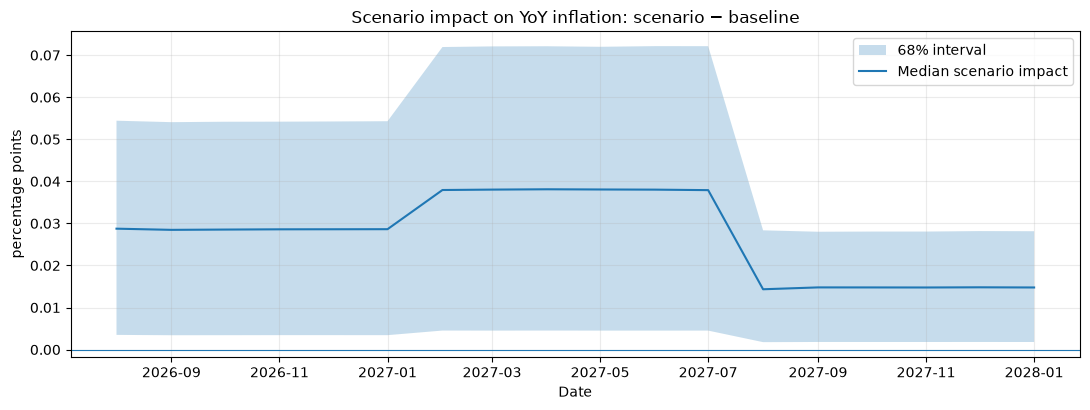

In [18]:
print("Permanent +1% PPI consumer-goods level shift")
display(headline_scenario_impact_table(ppi_baseline, ppi_scenario, kind="yoy"))
plot_headline_scenario_impact(ppi_baseline, ppi_scenario, kind="yoy")
plt.show()

print("Permanent +1% compensation-per-employee level shift")
display(headline_scenario_impact_table(wage_baseline, wage_scenario, kind="yoy"))
plot_headline_scenario_impact(wage_baseline, wage_scenario, kind="yoy")
plt.show()

print("Permanent +1% RELATIVE VAT-rate shift")
display(headline_scenario_impact_table(vat_baseline, vat_scenario, kind="yoy"))
plot_headline_scenario_impact(vat_baseline, vat_scenario, kind="yoy")
plt.show()

### Timing guard implied by the lag structure

If the level change is introduced in the first forecast month:

```text
VAT L0       → direct effect can begin in forecast month 1
PPI L1       → direct effect can begin in forecast month 2
WAGES L2     → direct effect can begin in forecast month 3
```

Subsequent propagation occurs through the target's active autoregressive lags 1, 6 and 12. These timing patterns are useful regression tests for the future dashboard scenario engine.

## 14. MCMC and stability diagnostics

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
log likelihood,1348.36,17.63,49.89,2.50,0.14
spectral radius,0.90,0.01,55.03,1.93 × 10⁻³,0.13
phi[state__hicp_neig],0.02,8.73 × 10⁻³,76.25,1.00 × 10⁻³,0.11
p_outlier[state__hicp_neig],0.01,6.78 × 10⁻³,126.19,6.04 × 10⁻⁴,0.09
own L1[state__hicp_neig],-1.35 × 10⁻³,0.04,169.97,2.98 × 10⁻³,0.08


,value
retained_draws,3000.000000
median_spectral_radius,0.895619
q95_spectral_radius,0.918644
maximum_spectral_radius,0.938815
retained_unstable_share,0.000000
B_total_proposals,6000.000000
B_unstable_proposals,0.000000
B_instability_rejection_rate,0.000000


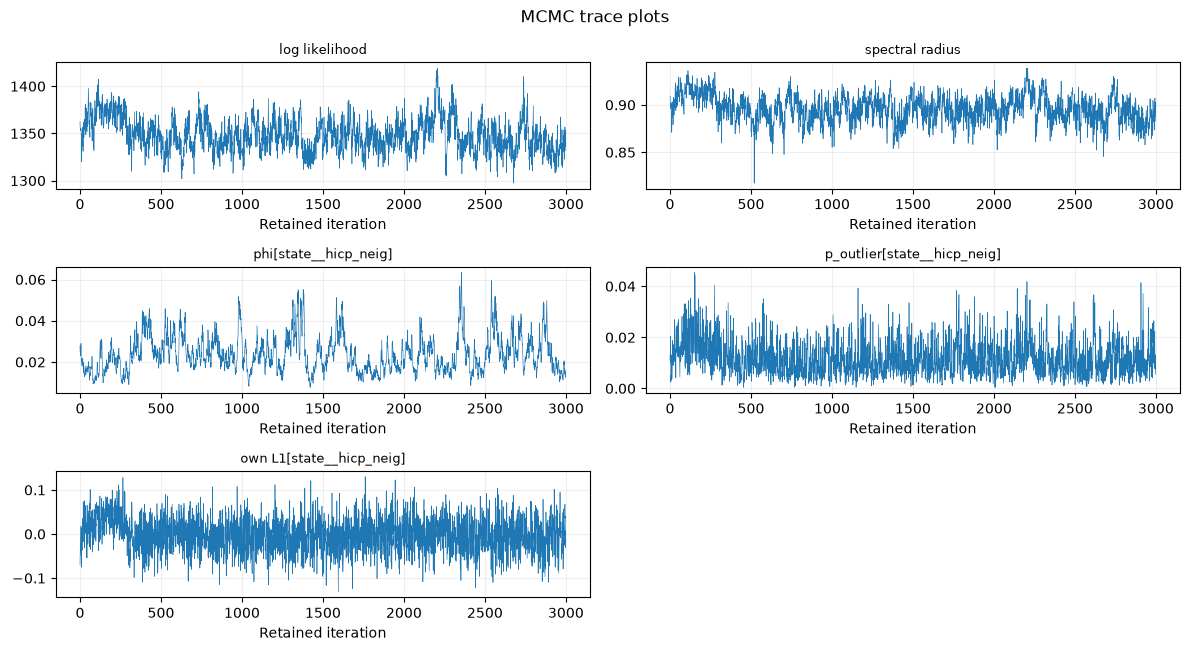

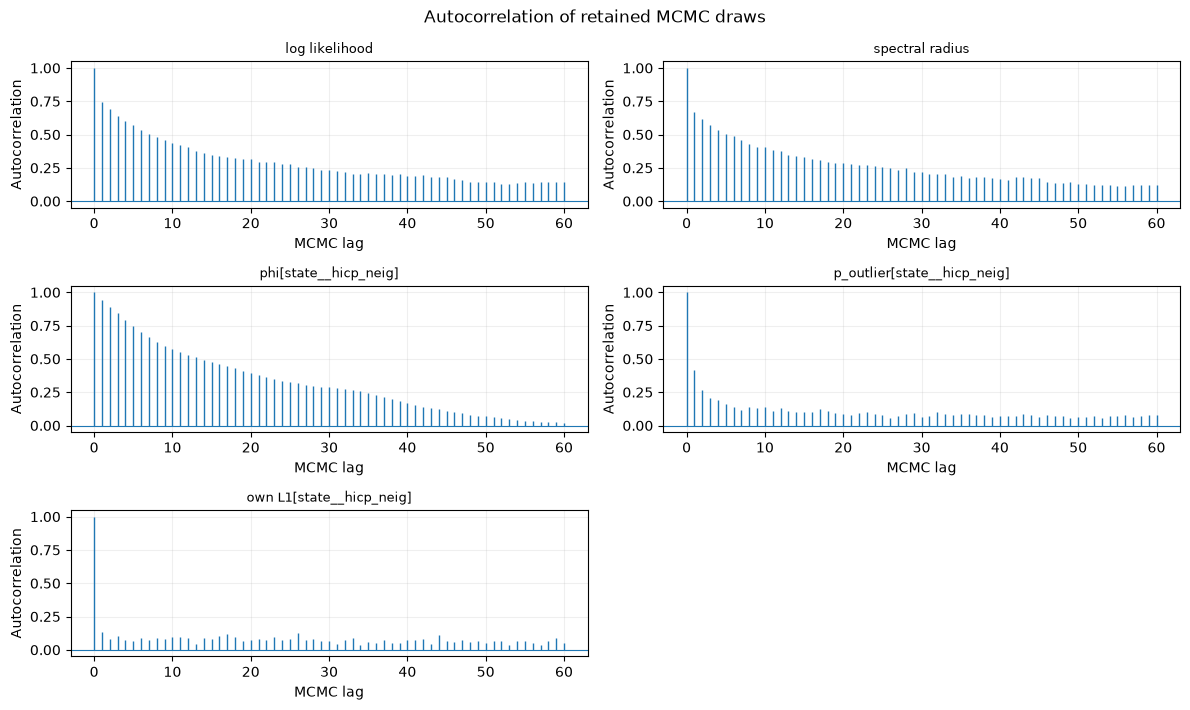

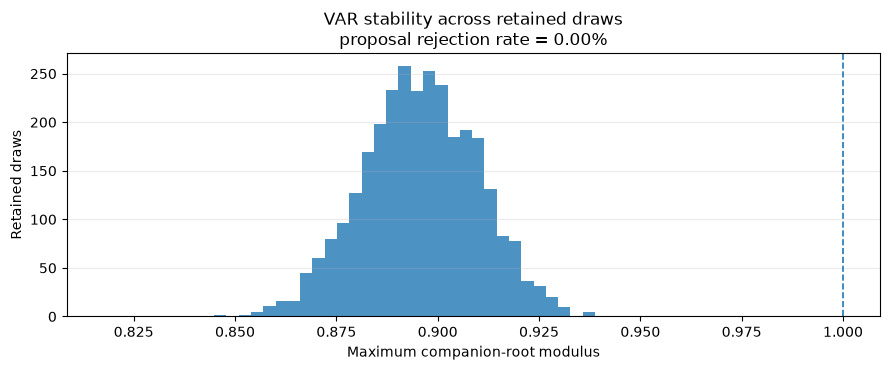

In [19]:
display(style_numeric_table(mcmc_diagnostics(result), caption="MCMC diagnostics"))
display(stability_diagnostics(result).to_frame("value"))

plot_trace_grid(result)
plt.show()

plot_chain_acf_grid(result)
plt.show()

plot_spectral_radius(result)
plt.show()

## 15. Stationarity diagnostics

In [20]:
transformed = native_model_differences(native_levels, COMPONENT)
# These tests use observed transformed data only; no trailing driver assumptions are inserted.
display(stationarity_tests(transformed.dropna()))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
hicp_neig,-2.722106,7.029045e-02,11,0.194355,0.10000,42,300
ppi_consumer_goods,-4.019495,1.311802e-03,13,0.267796,0.10000,10,298
compensation_per_employee,-3.111812,2.569134e-02,12,0.451841,0.05481,4,299
vat_standard_ea,-17.688598,3.580838e-30,0,0.205154,0.10000,1,311


## 16. Posterior predictive checks

,observed,replicated_median,replicated_q05,replicated_q95
state__hicp_neig: mean,7.30 × 10⁻⁴,6.44 × 10⁻⁴,-1.76 × 10⁻⁴,1.51 × 10⁻³
state__hicp_neig: sd,0.02,0.01,0.01,0.02
state__hicp_neig: maximum_absolute,0.04,0.04,0.03,0.08


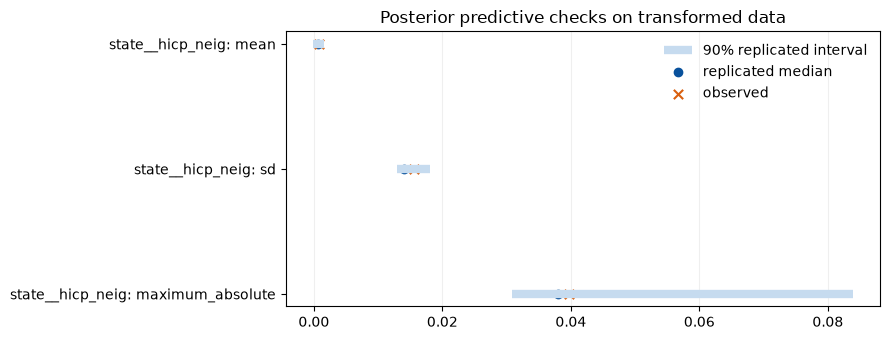

In [21]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=321,
)
display(style_numeric_table(ppc_summary, caption="Posterior predictive checks"))
plot_posterior_predictive_check(ppc_summary)
plt.show()

## 17. Save / common registry promotion

In [ ]:
if SAVE_RESULTS:
    if save_energy_bvar_result is None:
        raise RuntimeError("energy_bvar_io.save_energy_bvar_result is unavailable.")
    saved = save_energy_bvar_result(result, PROJECT_ROOT / "results")
    print("Saved to:", saved["directory"])
else:
    print("SAVE_RESULTS=False — estimation is not promoted to the common registry.")

SAVE_RESULTS=False — estimation is not promoted to the common registry.


: 

## Production contract

```text
neig_monthly.csv
    │
    ├─ hicp_neig                    → Δlog, endogenous
    │                                  active lags = {1, 6, 12}
    │                                  all other lags fixed exactly to zero
    │
    ├─ ppi_consumer_goods           → Δlog, L1 exogenous term
    ├─ compensation_per_employee    → Δlog, L2 exogenous term
    └─ vat_standard_ea              → Δ(rate/100), L0 exogenous term

+ 11 monthly dummies

        ↓
shared Energy Bayesian engine
(active_lags=[1,6,12])
        ↓
SV + model-based outliers + Gibbs + DK-compatible companion state
        ↓
conditional native-driver forecast paths
        ↓
NEIG HICP level draws
NEIG HICP YoY draws
        ↓
Headline aggregation → dashboard
```

The statistical engine remains shared. The WP374 component economics and transformation/conditioning contract live in `headline_bvar_model.py`.